In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
IMG_SIZE = 128
BATCH_SIZE = 16


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [4]:
train_generator=train_datagen.flow_from_directory(
    '/content/drive/MyDrive/DATA',
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DATA'

In [ ]:
val_generator=train_datagen.flow_from_directory(
    '/content/drive/MyDrive/DATA',
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

In [ ]:
class_indices=train_generator.class_indices
class_names=list(class_indices.keys())
print("class_indices:",class_indices)
print("class_names:",class_names)

In [ ]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu', input_shape=(IMG_SIZE,IMG_SIZE, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(4,activation='softmax'),
])

In [ ]:
model.summary()

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(train_generator,validation_data=val_generator,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 101s 10s/step - accuracy: 0.1527 - loss: 1.9415 - val_accuracy: 0.2125 - val_loss: 1.3890
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3647 - loss: 1.3678 - val_accuracy: 0.2625 - val_loss: 1.3941
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4475 - loss: 1.3352 - val_accuracy: 0.2500 - val_loss: 1.4108
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4256 - loss: 1.2117 - val_accuracy: 0.2562 - val_loss: 1.4717
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4613 - loss: 1.1741 - val_accuracy: 0.2500 - val_loss: 1.4415


In [ ]:
model.save('/content/drive/MyDrive/DATA.h5')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
model=load_model('/content/drive/MyDrive/DATA.h5')
print("model loaded")

model loaded


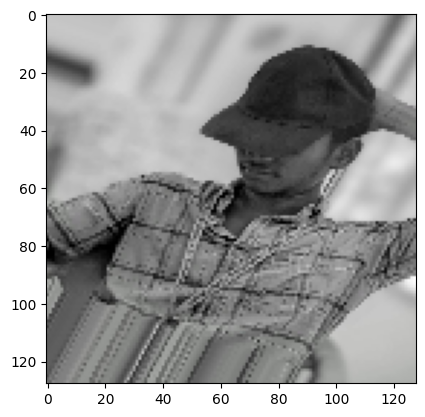

In [ ]:
test_image_path="/content/drive/MyDrive/DATA/Madhavans/aug_0_2226.jpg"
img=image.load_img(test_image_path,target_size=(128,128))
plt.imshow(img)
plt.axis()
plt.show()

In [ ]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array/=255

In [ ]:
perdiction=model.predict(img_array)
ind=np.argmax(perdiction[0])
print(class_names[ind])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Madhavans
